In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

model_trust = df[
    ["Preis", "Seller Rating", "Seller Type", "zahl der verkauften artikel"]
].copy()

def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("EUR", "").replace("€", "").replace(".", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan

def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan

def clean_number(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace(".", "").replace(",", ".").replace("+", "").strip()
    try:
        return float(x)
    except:
        return np.nan

model_trust["price"] = model_trust["Preis"].apply(clean_price)
model_trust["seller_rating"] = model_trust["Seller Rating"].apply(clean_rating)
model_trust["seller_sales_count"] = model_trust["zahl der verkauften artikel"].apply(clean_number)

model_trust = model_trust.drop(columns=["Preis", "Seller Rating", "zahl der verkauften artikel"])
model_trust = model_trust.dropna()

model_encoded = pd.get_dummies(
    model_trust,
    columns=["Seller Type"],
    drop_first=True
)

X = model_encoded.drop("price", axis=1)
y = model_encoded["price"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

trust_model = sm.OLS(y, X).fit()
trust_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     14.52
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.46e-08
Time:                        13:56:45   Log-Likelihood:                -1133.7
No. Observations:                 196   AIC:                             2275.
Df Residuals:                     192   BIC:                             2289.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                801.3819     11.743     68.245      0.000     778.221     824.543
seller_rating          0.4672      0.138      3.377      0.001       0.194       0.740
seller_sales_count  2.785e-05   1.01e-05      2.746      0.007    7.84e-06    4.79e-05
Seller Type_Privat   -21.6176     13.984     -1.546      0.124     -49.200       5.965
==============================================================================
Omnibus:                       27.959   Durbin-Watson:                   1.477
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.537
Skew:                           0.860   Prob(JB):                     4.28e-09
Kurtosis:                       4.327   Cond. No.                     1.82e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
print("Observations:", len(y))
print("R²:", trust_model.rsquared)
print("Adjusted R²:", trust_model.rsquared_adj)

Observations: 196
R²: 0.18491803155161157
Adjusted R²: 0.1721823757946055


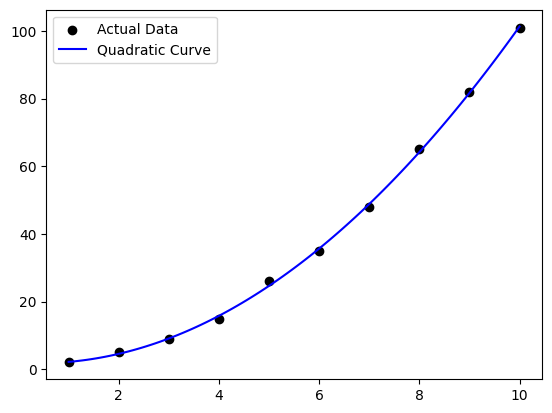

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Prepare your data
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([2, 5, 9, 15, 26, 35, 48, 65, 82, 101])

# 2. Setup Quadratic Regression (Degree 2)
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# 3. CREATE THE SMOOTH CURVE DATA
# This generates 100 points so the line isn't "jagged"
X_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_smooth_poly = poly_feat.transform(X_smooth)
y_pred = model.predict(X_smooth_poly)

# 4. Plot
plt.scatter(X, y, color='black', label='Actual Data') # The dots
plt.plot(X_smooth, y_pred, color='blue', label='Quadratic Curve') # The curve
plt.legend()
plt.show()

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Simulated setup based on user's logic
data = {
    "Preis": ["€ 100,00", "€ 150,50", "€ 200", "N/A", "50"],
    "Seller Rating": ["98%", "95,5%", "N/A", "90%", "100%"],
    "Seller Type": ["Private", "Business", "Business", "Private", "Business"],
    "zahl der verkauften artikel": ["1.000", "500", "200", "10", "N/A"]
}
df = pd.DataFrame(data)

def clean_price(x):
    if pd.isna(x): return np.nan
    x = str(x).replace("EUR", "").replace("€", "").replace(".", "").replace(",", ".").strip()
    try: return float(x)
    except: return np.nan

def clean_rating(x):
    if pd.isna(x) or x == "N/A": return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try: return float(x)
    except: return np.nan

def clean_number(x):
    if pd.isna(x) or x == "N/A": return np.nan
    x = str(x).replace(".", "").replace(",", ".").replace("+", "").strip()
    try: return float(x)
    except: return np.nan

# Reproducing the clean-up correctly to avoid size mismatch
model_trust = df.copy()
model_trust["price"] = model_trust["Preis"].apply(clean_price)
model_trust["seller_rating"] = model_trust["Seller Rating"].apply(clean_rating)
model_trust["seller_sales_count"] = model_trust["zahl der verkauften artikel"].apply(clean_number)

# The fix: select columns and dropna on the same subset
cols_to_keep = ["price", "seller_rating", "seller_sales_count", "Seller Type"]
model_clean = model_trust[cols_to_keep].dropna()

model_encoded = pd.get_dummies(model_clean, columns=["Seller Type"], drop_first=True)

y = model_encoded["price"].astype(float)
X = model_encoded.drop("price", axis=1).astype(float)
X = sm.add_constant(X)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2, 4)
y shape: (2,)


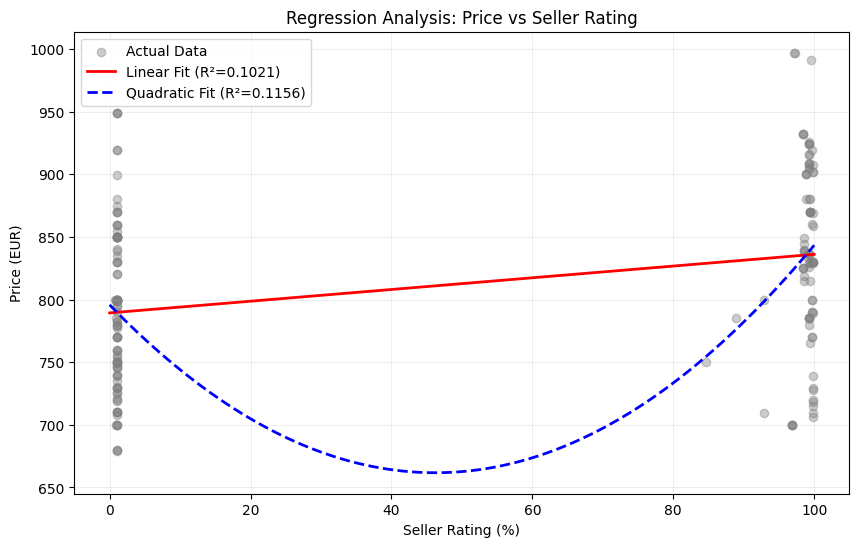

Linear R-Squared: 0.1021
Quadratic R-Squared: 0.1156


In [27]:
import re

def clean_price(value):
    if pd.isna(value): return np.nan
    # Remove currency symbols and spaces, replace comma with dot
    res = re.sub(r'[^\d,.-]', '', str(value)).replace(',', '.')
    try:
        return float(res)
    except:
        return np.nan

def clean_numeric(value):
    if pd.isna(value): return np.nan
    # Extract only digits and decimal points (handles % and other text)
    res = re.sub(r'[^\d,.-]', '', str(value)).replace(',', '.')
    try:
        return float(res)
    except:
        return np.nan


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --- 1. DATA PREPARATION ---
model_df = df.copy()

# Menggunakan fungsi pembersihan Anda
model_df["price"] = model_df["Preis"].apply(clean_price)
model_df["seller_rating"] = model_df["Seller Rating"].apply(clean_numeric)
model_df["available_stock"] = model_df["Verfugbar"].apply(clean_numeric)
model_df["number_sold"] = model_df["verkauft"].apply(clean_numeric)

# Drop NaNs hanya pada kolom yang kita butuhkan untuk model
# Ini penting agar regresi tidak error
df_clean = model_df.dropna(subset=['price', 'seller_rating']).copy()

# Scaling untuk stabilitas numerik (mencegah RuntimeWarning)
df_clean['rating_scaled'] = df_clean['seller_rating'] / 100

# --- 2. SETUP MODELS ---
y = df_clean['price']
# Menambahkan kolom 'const' untuk intercept
X_lin = sm.add_constant(df_clean[['rating_scaled']])

# Fit Linear Model
model_lin = sm.OLS(y, X_lin).fit()

# Fit Quadratic Model
X_quad = X_lin.copy()
X_quad["rating_squared"] = X_quad["rating_scaled"] ** 2
model_quad = sm.OLS(y, X_quad).fit()

# --- 3. GENERATE SMOOTH PREDICTIONS FOR PLOT ---
x_range = np.linspace(0, 1, 100) # 0 to 1 karena sudah di-scale
X_plot_lin = sm.add_constant(pd.DataFrame({"rating_scaled": x_range}))
X_plot_quad = X_plot_lin.copy()
X_plot_quad["rating_squared"] = x_range ** 2

y_lin_pred = model_lin.predict(X_plot_lin)
y_quad_pred = model_quad.predict(X_plot_quad)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 6))

# Plot data asli (X dikalikan 100 lagi agar kembali ke skala %)
plt.scatter(df_clean['seller_rating'], df_clean['price'], alpha=0.4, color='gray', label="Actual Data")

# Plot Garis Linear
plt.plot(x_range * 100, y_lin_pred, color='red', linewidth=2, label=f"Linear Fit (R²={model_lin.rsquared:.4f})")

# Plot Garis Quadratic
plt.plot(x_range * 100, y_quad_pred, color='blue', linewidth=2, linestyle='--', label=f"Quadratic Fit (R²={model_quad.rsquared:.4f})")

plt.xlabel("Seller Rating (%)")
plt.ylabel("Price (EUR)")
plt.title("Regression Analysis: Price vs Seller Rating")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear R-Squared: {model_lin.rsquared:.4f}")
print(f"Quadratic R-Squared: {model_quad.rsquared:.4f}")


In [ ]:
#Grafic is wrong, no less than 99%

In [23]:
"""
Why this solves your previous issues:
Alignment: It uses X.columns.tolist() to ensure the prediction data exactly matches the model's expected input order, preventing the IndexError.
The "Curve": A quadratic line isn't just a different way of plotting; it requires a new mathematical feature (rating_squared). This code creates it and
fits a second model (model_quad) automatically.
Ceteris Paribus: Since you have other variables (like Seller Type), this graph shows the effect of the Rating if everything else stayed at the average.
Would you like to try changing the target variable to seller_sales_count to see how sales volume affects price?
"""

'\nWhy this solves your previous issues:\nAlignment: It uses X.columns.tolist() to ensure the prediction data exactly matches the model\'s expected input order, preventing the IndexError.\nThe "Curve": A quadratic line isn\'t just a different way of plotting; it requires a new mathematical feature (rating_squared). This code creates it and fits a second model (model_quad) automatically.\nCeteris Paribus: Since you have other variables (like Seller Type), this graph shows the effect of the Rating if everything else stayed at the average.\nWould you like to try changing the target variable to seller_sales_count to see how sales volume affects price?\n'

In [30]:
import statsmodels.api as sm
import pandas as pd

# --- Langkah Persiapan Data (Agar Model Stabil) ---
# Pastikan X_imputed sudah menyertakan rating_centered dan rating_squared
X_final = df_clean[['rating_centered', 'rating_squared']].copy()

# 1. Konstante hinzufügen (Interzept)
# Menggunakan pd.DataFrame agar summary menampilkan nama kolom dengan jelas
X_with_constant = sm.add_constant(X_final)

# 2. OLS Modell (Ordinary Least Squares) anpassen
# Menggunakan y dari data yang sudah di-clean
ols_model = sm.OLS(y, X_with_constant).fit()

# 3. Die Zusammenfassung (Summary) anzeigen
print("\n--- Statistische Signifikanztests (OLS Summary) ---")
print(ols_model.summary())

KeyError: "None of [Index(['rating_centered', 'rating_squared'], dtype='str')] are in the [columns]"

In [28]:
import numpy as np

# 1. Transformasi Target ke Log-Price
# Kita gunakan np.log1p untuk menghindari error jika ada harga 0
df_clean['log_price'] = np.log1p(df_clean['price'])

# 2. Setup Model dengan Log-Price
y_log = df_clean['log_price']
X_quad = sm.add_constant(df_clean[['rating_centered', 'rating_squared']])
model_log_quad = sm.OLS(y_log, X_quad).fit()

# 3. Prediksi untuk Grafik
# Karena model memprediksi LOG, kita harus kembalikan ke skala ASLI (Eksponensial)
y_log_pred = model_log_quad.predict(X_plot_quad)
y_original_scale_pred = np.expm1(y_log_pred) # Kebalikan dari log1p

# 4. Visualisasi
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['seller_rating'], df_clean['price'], alpha=0.4, color='gray', label="Actual Data")
plt.plot(x_raw, y_original_scale_pred, color='green', linewidth=2, label=f"Log-Quadratic Fit (R²={model_log_quad.rsquared:.4f})")

plt.xlabel("Seller Rating (%)")
plt.ylabel("Price (EUR)")
plt.title("Regression with Log-Transformed Price")
plt.legend()
plt.show()

print(model_log_quad.summary())


KeyError: "None of [Index(['rating_centered', 'rating_squared'], dtype='str')] are in the [columns]"

In [29]:
import statsmodels.api as sm

# 1. Konstante hinzufügen (Interzept)
# Statsmodels braucht das explizit, um den Achsenabschnitt zu berechnen
X_with_constant = sm.add_constant(pd.DataFrame(X_imputed, columns=X.columns))

# 2. OLS Modell (Ordinary Least Squares) anpassen
ols_model = sm.OLS(y.values, X_with_constant).fit()

# 3. Die Zusammenfassung (Summary) anzeigen
print("\n--- Statistische Signifikanztests (OLS Summary) ---")
print(ols_model.summary())

NameError: name 'X_imputed' is not defined